In [3]:
#Import all the relevant libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

import optuna

from pathlib import Path

import pickle
%matplotlib inline

In [4]:
# ========= Path & imports =========
from pathlib import Path
import pandas as pd
import numpy as np

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors

# ========= Folder layout (based on your screenshot) =========
# This notebook lives in: SDL5_MP/transfer_learning
BASE = Path.cwd()  # -> .../SDL5_MP/transfer_learning

# Everything we generate will be saved inside transfer_learning/
artifacts_dir = BASE / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Original curated data lives next to this folder
curated_dir = BASE.parent / "data_curation" / "original_curated_with_embeddings_and_MW"

train_csv = curated_dir / "train_without_data_augmentation" / "final_train_df.csv"
test_csv  = curated_dir / "test_predictions" / "consensus_without_data_augmentation.csv"

print("Using curated_dir:", curated_dir)
print("Train path:", train_csv.exists(), train_csv)
print("Test  path:", test_csv.exists(), test_csv)

Using curated_dir: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/data_curation/original_curated_with_embeddings_and_MW
Train path: True /Users/sdl5_mp/Documents/GitHub/SDL5_MP/data_curation/original_curated_with_embeddings_and_MW/train_without_data_augmentation/final_train_df.csv
Test  path: True /Users/sdl5_mp/Documents/GitHub/SDL5_MP/data_curation/original_curated_with_embeddings_and_MW/test_predictions/consensus_without_data_augmentation.csv


In [27]:
# ========= Load TRAIN =========
train_df = pd.read_csv(train_csv)
print("Initial train shape:", train_df.shape)

# ========= 0) Remove compounds with MW > 1000 (keep this step) =========
print("Before filtering:", train_df.shape)
train_df = train_df[train_df["MW"] <= 1000].copy()
print("After filtering:", train_df.shape)

# ========= 1) Assign MP thresholds =========
t1, t2 = 50, 250
print(f"MP ranges (based on TRAIN): Low ≤ {t1}, Intermediate ({t1}, {t2}], High > {t2}")

# ========= 2) Define MP category function =========
def mp_default_thresholds(mp_series, t1=50, t2=250):
    return np.select(
        [mp_series <= t1, mp_series > t2],
        ["Low", "High"],
        default="Intermediate"
    )

# ========= 3) Create MP category column =========
train_df["MP_category_default"] = mp_default_thresholds(train_df["MP"], t1, t2)

print("Added MP_category_default column.")
display(train_df.head())


Initial train shape: (17633, 4)
Before filtering: (17633, 4)
After filtering: (17625, 4)
MP ranges (based on TRAIN): Low ≤ 50, Intermediate (50, 250], High > 250
Added MP_category_default column.


,SMILES,MP,embeddings,MW,MP_category_default
0,FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...,-20.0,"tensor([3.5142e-01, 9.1762e-01, 8.4583e-02, 3....",624.106,Low
1,CCc1ncc[nH]1,82.0,"tensor([2.2764e-01, 0.0000e+00, 0.0000e+00, 8....",96.133,Intermediate
2,S=C(N(C)C)Sc1ccc2c(c1)cccc2,114.0,"tensor([3.4984e-01, 4.8049e-02, 8.2259e-02, 2....",247.388,Intermediate
3,Nc1nc(N)nc(n1)c1ccccc1,227.0,"tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 3....",187.206,Intermediate
4,NCCNc1ccc(cn1)[N+](=O)[O-],127.0,"tensor([7.3705e-02, 7.5921e-02, 1.7240e-01, 1....",182.183,Intermediate


In [28]:
# ========= Function: Add RDKit Descriptors =========
def add_rdkit_descriptors(df, smiles_col="SMILES", invalid_log_path=None):
    """
    - Computes ALL RDKit 2D descriptors (Descriptors.descList) for unique SMILES.
    - Removes rows with invalid SMILES from the returned dataframe.
    - Returns:
        merged_df : original df (only valid SMILES rows) + descriptor columns
        invalid_df: rows that were dropped because SMILES couldn't be parsed
    - Does NOT drop NaNs in descriptors and does NOT remove zero-variance columns.
    """
    if "SMLIES" in df.columns and smiles_col == "SMILES":
        df = df.rename(columns={"SMLIES": "SMILES"})
        smiles_col = "SMILES"

    assert smiles_col in df.columns, f"Column '{smiles_col}' not found."

    smiles_series = df[smiles_col].astype(str)
    unique_smiles = pd.Series(smiles_series.unique(), name=smiles_col)

    # Build descriptor metadata
    desc_list = Descriptors.descList
    desc_names = [name for name, _ in desc_list]
    desc_funcs = [func for _, func in desc_list]

    valid_rows, invalid_smiles = [], []
    for s in unique_smiles:
        mol = Chem.MolFromSmiles(s) if isinstance(s, str) and len(s) > 0 else None
        if mol is None:
            invalid_smiles.append(s)
            continue
        vals = []
        for f in desc_funcs:
            try:
                vals.append(f(mol))
            except Exception:
                vals.append(np.nan)
        valid_rows.append([s] + vals)

    desc_df = pd.DataFrame(valid_rows, columns=[smiles_col] + desc_names)

    invalid_mask = smiles_series.isin(invalid_smiles)
    invalid_df = df.loc[invalid_mask, [smiles_col]].copy()
    invalid_df = invalid_df.assign(reason="RDKit parse failed")
    invalid_df.insert(0, "row_index", invalid_df.index)

    if invalid_log_path is not None:
        invalid_log_path = Path(invalid_log_path)
        invalid_log_path.parent.mkdir(parents=True, exist_ok=True)
        invalid_df.to_csv(invalid_log_path, index=False)

    valid_mask = ~invalid_mask
    df_valid = df.loc[valid_mask].copy()
    merged_df = df_valid.merge(desc_df, on=smiles_col, how="left")

    print(f"Total rows in input: {len(df)}")
    print(f"Invalid SMILES rows removed: {invalid_df.shape[0]}")
    print(f"Rows returned (valid): {merged_df.shape[0]}")
    print(f"Descriptor columns added: {len(desc_names)}")

    return merged_df, invalid_df

# ========= Add RDKit descriptors to filtered TRAIN =========
merged_train_df, invalid_train = add_rdkit_descriptors(
    train_df,
    smiles_col="SMILES",
    invalid_log_path=artifacts_dir / "invalid_smiles_train.csv"
)

# ========= Cleaning RDKit features (NaN/Inf + zero variance) =========
base_cols = set(train_df.columns)
rdkit_cols = [c for c in merged_train_df.columns if c not in base_cols]

df = merged_train_df.copy()
df[rdkit_cols] = df[rdkit_cols].replace([np.inf, -np.inf], np.nan)

nan_inf_cols = [c for c in rdkit_cols if df[c].isna().any()]
remaining_cols = [c for c in rdkit_cols if c not in nan_inf_cols]
remaining_numeric = [c for c in remaining_cols if pd.api.types.is_numeric_dtype(df[c])]
nunique = df[remaining_numeric].nunique(dropna=False)
zero_var_cols = nunique.index[nunique <= 1].tolist()

# Create drop log
all_drop = sorted(set(nan_inf_cols).union(zero_var_cols))
reasons = []
for col in all_drop:
    r = []
    if col in nan_inf_cols: r.append("nan_or_inf")
    if col in zero_var_cols: r.append("zero_variance")
    reasons.append(";".join(r))
dropped_log = pd.DataFrame({"feature": all_drop, "reason": reasons})
dropped_log_path = artifacts_dir / "rdkit_features_dropped_log_train.csv"
dropped_log.to_csv(dropped_log_path, index=False)

# Drop unwanted RDKit columns
cols_to_drop = set(all_drop)
clean_cols = [c for c in df.columns if c not in cols_to_drop]
clean_df = df[clean_cols].copy()

# Save final outputs
final_train_out = artifacts_dir / "final_train_df_with_rdkit_all_descriptors_cleaned.csv"
clean_df.to_csv(final_train_out, index=False)

# Logs
pd.Series([c for c in rdkit_cols if c not in cols_to_drop], name="retained_rdkit_features").to_csv(
    artifacts_dir / "rdkit_features_retained_train.csv", index=False
)

print("\n=== TRAIN REPORT ===")
print(f"Original RDKit features: {len(rdkit_cols)}")
print(f"Dropped (NaN/∞): {len(nan_inf_cols)}")
print(f"Dropped (zero variance): {len(zero_var_cols)}")
print(f"Remaining: {len(rdkit_cols) - len(all_drop)}")
print(f"Saved cleaned dataset -> {final_train_out}")
print(f"Saved drop log -> {dropped_log_path}")

Total rows in input: 17625
Invalid SMILES rows removed: 0
Rows returned (valid): 17625
Descriptor columns added: 217

=== TRAIN REPORT ===
Original RDKit features: 217
Dropped (NaN/∞): 12
Dropped (zero variance): 3
Remaining: 202
Saved cleaned dataset -> /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_df_with_rdkit_all_descriptors_cleaned.csv
Saved drop log -> /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/rdkit_features_dropped_log_train.csv


In [ ]:
from pathlib import Path
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# ========= Paths =========
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"

# Load cleaned train data
train_clean_path = artifacts_dir / "final_train_df_with_rdkit_all_descriptors_cleaned.csv"
train_df = pd.read_csv(train_clean_path)
print("Loaded train:", train_df.shape)

# Identify columns to scale — exclude non-numeric or non-feature columns
exclude_cols = ["SMILES", "MP", "MW", "MP_category_default"]    # embedings excluded too because it is not numeric !!
feature_cols = [c for c in train_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(train_df[c])]

print(f"Scaling {len(feature_cols)} numeric feature columns...")

# ========= Fit StandardScaler =========
scaler = StandardScaler()
train_scaled_values = scaler.fit_transform(train_df[feature_cols])

# Create scaled DataFrame (keep same column names)
scaled_df = pd.DataFrame(train_scaled_values, columns=feature_cols, index=train_df.index)

# Add back non-scaled columns (SMILES, etc.)
final_scaled_train = pd.concat([train_df[exclude_cols], scaled_df], axis=1)

# ========= Save outputs =========
scaled_out_path = artifacts_dir / "final_train_df_scaled.csv"
scaler_path = artifacts_dir / "standard_scaler_train.joblib"

final_scaled_train.to_csv(scaled_out_path, index=False)
joblib.dump(scaler, scaler_path)

print(f"✅ Scaled data saved to: {scaled_out_path}")
print(f"✅ Scaler saved to: {scaler_path}")
print("Scaled train shape:", final_scaled_train.shape)


Loaded train: (17625, 207)
Scaling 202 numeric feature columns...
✅ Scaled data saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_df_scaled.csv
✅ Scaler saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/standard_scaler_train.joblib
Scaled train shape: (17625, 206)


In [30]:
# 1️⃣ Quick summary statistics
print(final_scaled_train[feature_cols].describe().T[['mean', 'std']].head(10))

                             mean       std
MaxAbsEStateIndex   -4.120140e-16  1.000028
MaxEStateIndex       7.659751e-17  1.000028
MinAbsEStateIndex    7.337236e-17  1.000028
MinEStateIndex       4.837738e-18  1.000028
qed                  3.507360e-16  1.000028
SPS                  1.648862e-16  1.000028
MolWt               -4.112077e-17  1.000028
HeavyAtomMolWt       1.572265e-17  1.000028
ExactMolWt          -2.531749e-16  1.000028
NumValenceElectrons -1.798026e-16  1.000028


In [31]:
from pathlib import Path
import pandas as pd

# Paths
BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
scaled_train_path = artifacts_dir / "final_train_df_scaled.csv"

# Load scaled train data
train_scaled_df = pd.read_csv(scaled_train_path)
print("Loaded scaled train:", train_scaled_df.shape)

# Check category distribution
print(train_scaled_df["MP_category_default"].value_counts())

# Split by MW_category_default
low_df  = train_scaled_df[train_scaled_df["MP_category_default"] == "Low"].copy()
mid_df  = train_scaled_df[train_scaled_df["MP_category_default"] == "Intermediate"].copy()
high_df = train_scaled_df[train_scaled_df["MP_category_default"] == "High"].copy()

# Save each subset
low_path  = artifacts_dir / "final_train_low_MP_scaled.csv"
mid_path  = artifacts_dir / "final_train_intermediate_MP_scaled.csv"
high_path = artifacts_dir / "final_train_high_MP_scaled.csv"

low_df.to_csv(low_path, index=False)
mid_df.to_csv(mid_path, index=False)
high_df.to_csv(high_path, index=False)

print("\n✅ Split complete:")
print(f"Low-MP dataset saved to:          {low_path}   ({len(low_df)} rows)")
print(f"Intermediate-MP dataset saved to: {mid_path}   ({len(mid_df)} rows)")
print(f"High-MP dataset saved to:         {high_path}  ({len(high_df)} rows)")


Loaded scaled train: (17625, 206)
MP_category_default
Intermediate    12191
Low              4662
High              772
Name: count, dtype: int64

✅ Split complete:
Low-MP dataset saved to:          /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_low_MP_scaled.csv   (4662 rows)
Intermediate-MP dataset saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_intermediate_MP_scaled.csv   (12191 rows)
High-MP dataset saved to:         /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_high_MP_scaled.csv  (772 rows)


In [32]:
from pathlib import Path

# Define the base path (current working folder is transfer_learning)
BASE = Path.cwd()

# Path to the low-Mw scaled training dataset
low_mw_train_path = BASE / "artifacts" / "final_train_low_MP_scaled.csv"

print("low-Mw dataset path:", low_mw_train_path)

low-Mw dataset path: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_low_MP_scaled.csv


In [33]:
import pandas as pd

int_df = pd.read_csv(low_mw_train_path)
print("Loaded Low-Mw dataset:", int_df.shape)
int_df.head()


Loaded Low-Mw dataset: (4662, 206)


,SMILES,MP,MW,MP_category_default,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...,-20.0,624.106,Low,1.799400,1.799413,16.894265,-6.133933,-2.010495,3.352459,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
1,ClC(C(Cl)(Cl)F)Cl,-82.6,185.840,Low,0.677829,0.677853,2.050935,-1.271113,-0.140445,-0.196699,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
2,OC1CCCCC1,24.0,100.161,Low,-0.232345,-0.232313,-0.681013,0.447609,-0.546110,1.081462,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
3,CCc1cc(CC)cc(c1)C,-74.0,148.249,Low,-2.329227,-2.329174,1.557149,1.193758,0.184934,-0.481180,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
4,CC(C(C(C)(C)C)C)O,27.0,130.231,Low,-0.153889,-0.153857,-0.371076,0.296117,0.008073,0.469316,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273


Loaded Low-MP scaled data: (4662, 206)
RDKit feature matrix shape: (4662, 202)


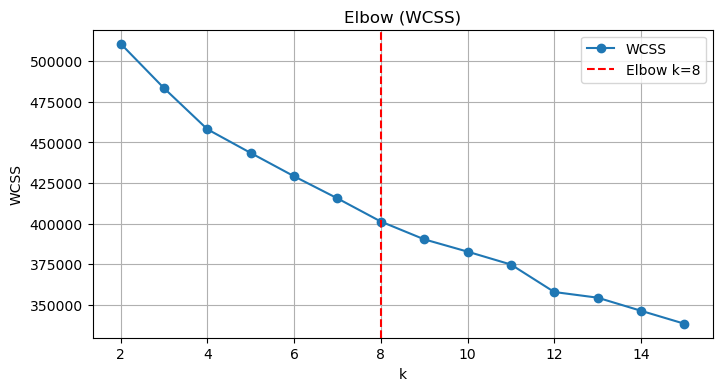

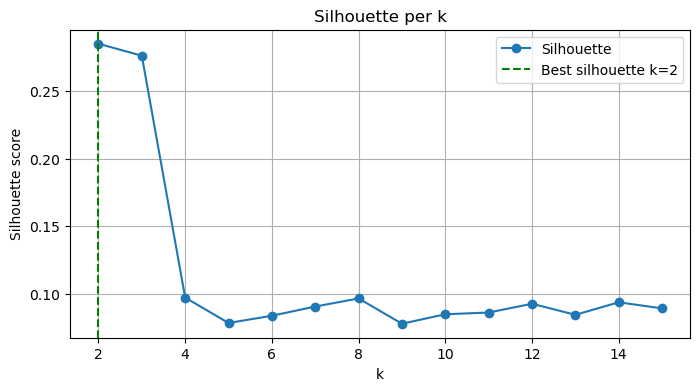

Elbow k: 8 | Best silhouette k: 2 | Selected k_opt: 8

Assigned Structure_Cluster using RDKit features with k=8.
                                              SMILES  Structure_Cluster
0  FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...                  3
1                                  ClC(C(Cl)(Cl)F)Cl                  1
2                                          OC1CCCCC1                  2
3                                  CCc1cc(CC)cc(c1)C                  5
4                                  CC(C(C(C)(C)C)C)O                  2

✅ Clustered Low-Mw dataset saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_low_MP_scaled_clustered.csv


In [35]:
# ========= Clustering RDKit features for Low-Mw data =========
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# ---------------------------------------------------------------------
# 1) Load Low-Mw scaled dataset
# ---------------------------------------------------------------------
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"
low_mw_train_path = artifacts_dir / "final_train_low_MP_scaled.csv"

int_df = pd.read_csv(low_mw_train_path)
print("Loaded Low-MP scaled data:", int_df.shape)

# ---------------------------------------------------------------------
# 2) Select RDKit features only
# ---------------------------------------------------------------------
# Exclude non-feature columns
exclude_cols = ["SMILES", "MP", "embeddings", "MW", "MP_category_default"]
rdk_cols = [c for c in int_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(int_df[c])]

X_rdk_scaled = int_df[rdk_cols].values
print(f"RDKit feature matrix shape: {X_rdk_scaled.shape}")

# ---------------------------------------------------------------------
# 3) Function: Find optimal k for KMeans
# ---------------------------------------------------------------------
def find_optimal_clusters_rdk(X_scaled, max_k=15, random_state=0, plot=True):
    ks, wcss, sils = list(range(2, max_k + 1)), [], []
    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        try:
            sils.append(silhouette_score(X_scaled, labels))
        except Exception:
            sils.append(np.nan)

    kn = KneeLocator(ks, wcss, curve="convex", direction="decreasing")
    k_elbow = kn.elbow
    k_sil = ks[int(np.nanargmax(sils))] if np.isfinite(sils).any() else None
    k_opt = k_elbow if k_elbow is not None else k_sil

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, wcss, marker="o", label="WCSS")
        if k_elbow is not None:
            ax.axvline(k_elbow, linestyle="--", color="r", label=f"Elbow k={k_elbow}")
        ax.set(xlabel="k", ylabel="WCSS", title="Elbow (WCSS)")
        ax.grid(True); ax.legend(); plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, sils, marker="o", label="Silhouette")
        if k_sil is not None:
            ax.axvline(k_sil, linestyle="--", color="g", label=f"Best silhouette k={k_sil}")
        ax.set(xlabel="k", ylabel="Silhouette score", title="Silhouette per k")
        ax.grid(True); ax.legend(); plt.show()

    print(f"Elbow k: {k_elbow} | Best silhouette k: {k_sil} | Selected k_opt: {k_opt}")
    return k_opt

# ---------------------------------------------------------------------
# 4) Find optimal number of clusters
# ---------------------------------------------------------------------
k_opt = find_optimal_clusters_rdk(X_rdk_scaled, max_k=15, random_state=0, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

# ---------------------------------------------------------------------
# 5) Apply KMeans clustering
# ---------------------------------------------------------------------
final_kmeans = KMeans(n_clusters=int(k_opt), init="k-means++", n_init=10, random_state=0)
int_df["Structure_Cluster"] = final_kmeans.fit_predict(X_rdk_scaled)

print(f"\nAssigned Structure_Cluster using RDKit features with k={k_opt}.")
print(int_df[["SMILES", "Structure_Cluster"]].head())

# ---------------------------------------------------------------------
# 6) Save the clustered dataset
# ---------------------------------------------------------------------
clustered_out_path = artifacts_dir / "final_train_low_MP_scaled_clustered.csv"
int_df.to_csv(clustered_out_path, index=False)
print(f"\n✅ Clustered Low-Mw dataset saved to: {clustered_out_path}")

In [36]:
from pathlib import Path

# Define the base path (current working folder is transfer_learning)
BASE = Path.cwd()

# Path to the low-Mw scaled training dataset
low_mw_train_path = BASE / "artifacts" / "final_train_high_MP_scaled.csv"

print("High-Mw dataset path:", low_mw_train_path)

High-Mw dataset path: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_high_MP_scaled.csv


In [37]:
import pandas as pd

int_df = pd.read_csv(low_mw_train_path)
print("Loaded High-Mw dataset:", int_df.shape)
int_df.head()


Loaded High-Mw dataset: (772, 206)


,SMILES,MP,MW,MP_category_default,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,c1ccc(cc1)C1N=c2c(=N1)cccc2,293.0,194.237,High,-1.613437,-1.613391,-0.648109,0.388473,0.525015,-0.065455,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
1,Nc1ccc(c2c1C(=O)c1c(Cl)ccc(c1C2=O)Cl)[N+](=O)[O-],307.0,337.118,High,0.953863,0.953884,-0.753026,-0.075300,-0.976517,-0.200706,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
2,CCOC(=O)C12C(c3cc(Cl)ccc3O[P@@]2(=O)OCC)C2(C1c...,257.0,633.354,High,1.705482,1.705496,-0.682095,-2.647540,-2.144718,1.879945,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
3,OC(=O)c1cc(Cl)c(c(c1)Cl)N,291.5,206.028,High,0.259129,0.259157,-0.698817,-0.304382,0.731777,-0.507669,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273
4,Cn1nc2c(n1)ccc(c2)NC(=O)c1ccc(cc1)[N+](=O)[O-],280.0,297.274,High,0.784334,0.784357,-0.636791,0.081045,0.090096,-0.429760,...,-0.161814,-0.128107,-0.098496,-0.076121,-0.048874,-0.122138,-0.023587,-0.12239,-0.195542,-0.134273


Loaded High-MP scaled data: (772, 206)
RDKit feature matrix shape: (772, 202)


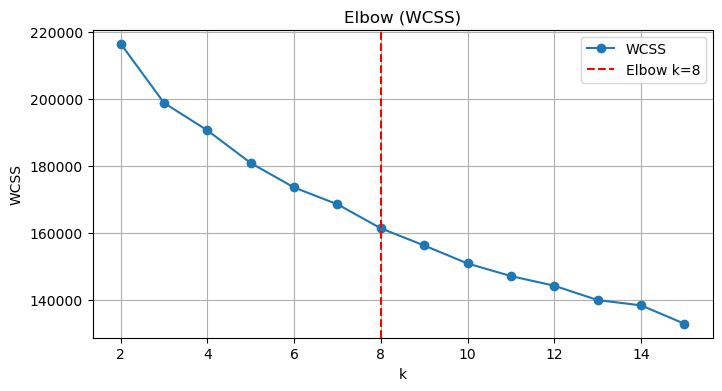

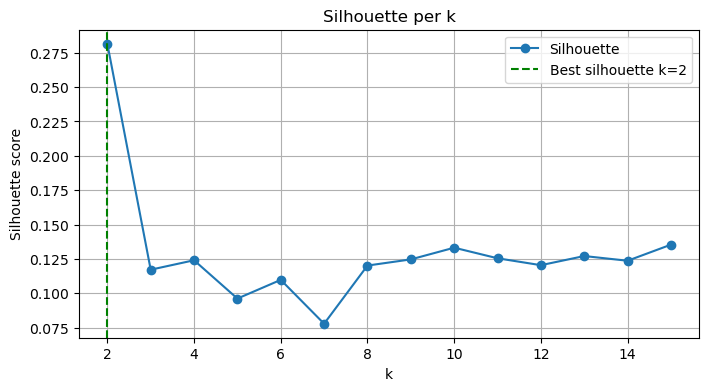

Elbow k: 8 | Best silhouette k: 2 | Selected k_opt: 8

Assigned Structure_Cluster using RDKit features with k=8.
                                              SMILES  Structure_Cluster
0                        c1ccc(cc1)C1N=c2c(=N1)cccc2                  6
1  Nc1ccc(c2c1C(=O)c1c(Cl)ccc(c1C2=O)Cl)[N+](=O)[O-]                  1
2  CCOC(=O)C12C(c3cc(Cl)ccc3O[P@@]2(=O)OCC)C2(C1c...                  4
3                          OC(=O)c1cc(Cl)c(c(c1)Cl)N                  6
4     Cn1nc2c(n1)ccc(c2)NC(=O)c1ccc(cc1)[N+](=O)[O-]                  1

✅ Clustered High-Mw dataset saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_high_MP_scaled_clustered.csv


In [ ]:
# ========= Clustering RDKit features for High-Mw data =========
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# ---------------------------------------------------------------------
# 1) Load Low-Mw scaled dataset
# ---------------------------------------------------------------------
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"
high_mw_train_path = artifacts_dir / "final_train_high_MP_scaled.csv"

int_df = pd.read_csv(high_mw_train_path)
print("Loaded High-MP scaled data:", int_df.shape)

# ---------------------------------------------------------------------
# 2) Select RDKit features only
# ---------------------------------------------------------------------
# Exclude non-feature columns
exclude_cols = ["SMILES", "MP", "embeddings", "MW", "MP_category_default"]
rdk_cols = [c for c in int_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(int_df[c])]

X_rdk_scaled = int_df[rdk_cols].values
print(f"RDKit feature matrix shape: {X_rdk_scaled.shape}")

# ---------------------------------------------------------------------
# 3) Function: Find optimal k for KMeans
# ---------------------------------------------------------------------
def find_optimal_clusters_rdk(X_scaled, max_k=15, random_state=0, plot=True):
    ks, wcss, sils = list(range(2, max_k + 1)), [], []
    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        try:
            sils.append(silhouette_score(X_scaled, labels))
        except Exception:
            sils.append(np.nan)

    kn = KneeLocator(ks, wcss, curve="convex", direction="decreasing")
    k_elbow = kn.elbow
    k_sil = ks[int(np.nanargmax(sils))] if np.isfinite(sils).any() else None
    k_opt = k_elbow if k_elbow is not None else k_sil

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, wcss, marker="o", label="WCSS")
        if k_elbow is not None:
            ax.axvline(k_elbow, linestyle="--", color="r", label=f"Elbow k={k_elbow}")
        ax.set(xlabel="k", ylabel="WCSS", title="Elbow (WCSS)")
        ax.grid(True); ax.legend(); plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, sils, marker="o", label="Silhouette")
        if k_sil is not None:
            ax.axvline(k_sil, linestyle="--", color="g", label=f"Best silhouette k={k_sil}")
        ax.set(xlabel="k", ylabel="Silhouette score", title="Silhouette per k")
        ax.grid(True); ax.legend(); plt.show()

    print(f"Elbow k: {k_elbow} | Best silhouette k: {k_sil} | Selected k_opt: {k_opt}")
    return k_opt

# ---------------------------------------------------------------------
# 4) Find optimal number of clusters
# ---------------------------------------------------------------------
k_opt = find_optimal_clusters_rdk(X_rdk_scaled, max_k=15, random_state=0, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

# ---------------------------------------------------------------------
# 5) Apply KMeans clustering
# ---------------------------------------------------------------------
final_kmeans = KMeans(n_clusters=int(k_opt), init="k-means++", n_init=10, random_state=0)
int_df["Structure_Cluster"] = final_kmeans.fit_predict(X_rdk_scaled)

print(f"\nAssigned Structure_Cluster using RDKit features with k={k_opt}.")
print(int_df[["SMILES", "Structure_Cluster"]].head())

# ---------------------------------------------------------------------
# 6) Save the clustered dataset
# ---------------------------------------------------------------------
clustered_out_path = artifacts_dir / "final_train_high_MP_scaled_clustered.csv"
int_df.to_csv(clustered_out_path, index=False)
print(f"\n✅ Clustered High-Mw dataset saved to: {clustered_out_path}")

In [42]:
df_int = pd.read_csv("artifacts/final_train_int_MP_scaled_clustered.csv") 
df_int.head(10)
print(df_int.shape)

(12191, 207)


In [43]:
df_high = pd.read_csv("artifacts/final_train_high_MP_scaled_clustered.csv") 
print(df_high.shape)

(772, 207)


In [44]:
df_low = pd.read_csv("artifacts/final_train_low_MP_scaled_clustered.csv") 
print(df_low.shape)

(4662, 207)


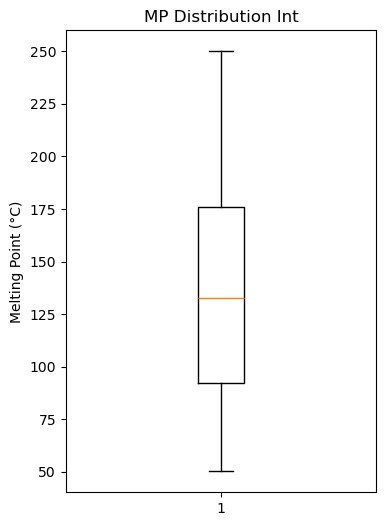

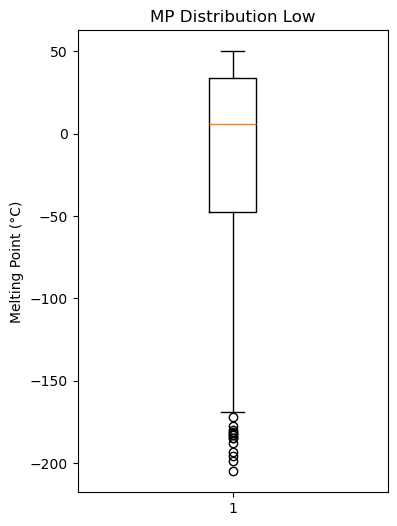

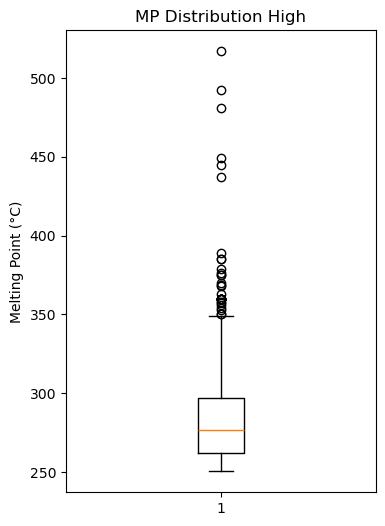

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("artifacts/final_train_int_MP_scaled_clustered.csv")

plt.figure(figsize=(4, 6))
plt.boxplot(df["MP"], vert=True)
plt.ylabel("Melting Point (°C)")
plt.title("MP Distribution Int")
plt.show()



df_low = pd.read_csv("artifacts/final_train_low_MP_scaled_clustered.csv")

plt.figure(figsize=(4, 6))
plt.boxplot(df_low["MP"], vert=True)
plt.ylabel("Melting Point (°C)")
plt.title("MP Distribution Low")
plt.show()


df_high = pd.read_csv("artifacts/final_train_high_MP_scaled_clustered.csv")

plt.figure(figsize=(4, 6))
plt.boxplot(df_high["MP"], vert=True)
plt.ylabel("Melting Point (°C)")
plt.title("MP Distribution High")
plt.show()



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_40382/1550543523.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=list(files.keys()))


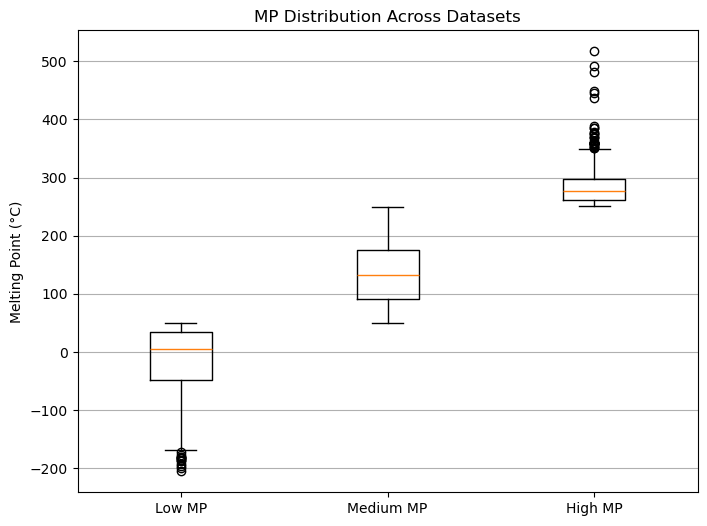

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "Low MP": "artifacts/final_train_low_MP_scaled_clustered.csv",
    "Medium MP": "artifacts/final_train_int_MP_scaled_clustered.csv",
    "High MP": "artifacts/final_train_high_MP_scaled_clustered.csv"
}

data = []

for label, path in files.items():
    df = pd.read_csv(path)
    data.append(df["MP"])

plt.figure(figsize=(8, 6))
plt.boxplot(data, labels=list(files.keys()))
plt.ylabel("Melting Point (°C)")
plt.title("MP Distribution Across Datasets")
plt.grid(axis="y")
plt.show()


=== Low MP ===
Rows: 4662
Min MP: -205.0
Max MP: 50.0
Mean MP: -10.721214071214073
Median MP: 6.0

=== Medium MP ===
Rows: 12191
Min MP: 50.25
Max MP: 250.0
Mean MP: 135.8528955787056
Median MP: 132.5

=== High MP ===
Rows: 772
Min MP: 250.5
Max MP: 517.0
Mean MP: 283.92998704663216
Median MP: 277.0


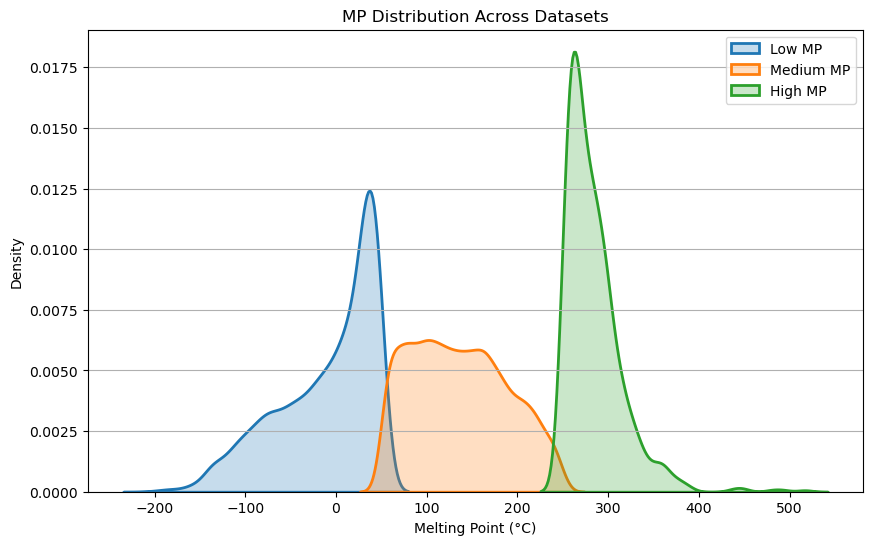

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

files = {
    "Low MP": "artifacts/final_train_low_MP_scaled_clustered.csv",
    "Medium MP": "artifacts/final_train_int_MP_scaled_clustered.csv",
    "High MP": "artifacts/final_train_high_MP_scaled_clustered.csv",
}

plt.figure(figsize=(10, 6))

for label, path in files.items():
    df = pd.read_csv(path)
    
    # Print stats
    print(f"\n=== {label} ===")
    print("Rows:", len(df))
    print("Min MP:", df["MP"].min())
    print("Max MP:", df["MP"].max())
    print("Mean MP:", df["MP"].mean())
    print("Median MP:", df["MP"].median())
    
    # KDE distribution plot
    sns.kdeplot(df["MP"], fill=True, label=label, linewidth=2)

plt.xlabel("Melting Point (°C)")
plt.ylabel("Density")
plt.title("MP Distribution Across Datasets")
plt.legend()
plt.grid(axis="y")
plt.show()


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_40382/2551390596.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=True)


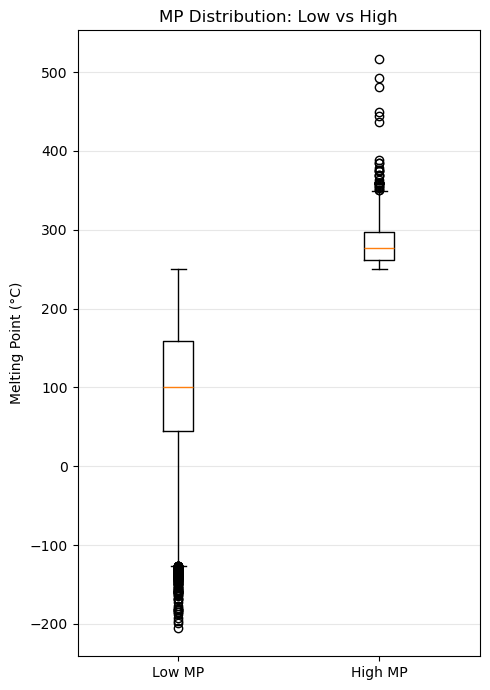

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "Low MP": "artifacts/final_train_low&int_MP_scaled_clustered.csv",
    "High MP": "artifacts/final_train_high_MP_scaled_clustered.csv",
}

data = []
labels = []

for label, path in files.items():
    df = pd.read_csv(path)
    data.append(df["MP"])   # continuous MP values
    labels.append(label)

plt.figure(figsize=(5,7))
plt.boxplot(data, labels=labels, showfliers=True)
plt.ylabel("Melting Point (°C)")
plt.title("MP Distribution: Low vs High")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


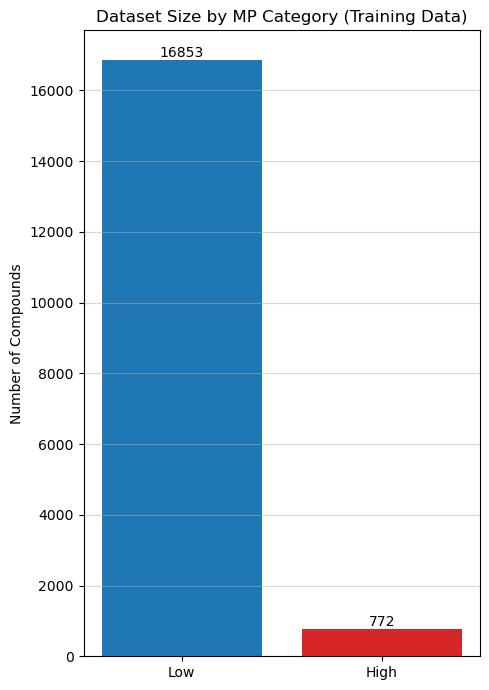

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
df_low_int = pd.read_csv(
    "artifacts/final_train_low&int_MP_scaled_clustered.csv"
)
df_high = pd.read_csv(
    "artifacts/final_train_high_MP_scaled_clustered.csv"
)

counts = {
    "Low": len(df_low_int),
    "High": len(df_high),
}

plt.figure(figsize=(5, 7))
plt.bar(counts.keys(), counts.values(), color=["#1f77b4", "#d62728"])

plt.ylabel("Number of Compounds")
plt.title("Dataset Size by MP Category (Training Data)")
plt.grid(axis="y", alpha=0.5)

for i, v in enumerate(counts.values()):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [50]:
from pathlib import Path
import pandas as pd

# Paths
BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
scaled_train_path = artifacts_dir / "final_train_df_scaled.csv"

# Load scaled train data
train_scaled_df = pd.read_csv(scaled_train_path)
print("Loaded scaled train:", train_scaled_df.shape)

# Check category distribution
print(train_scaled_df["MP_category_default"].value_counts())


# 👉 New: combined Low + Intermediate subset
low_mid_df = train_scaled_df[
    train_scaled_df["MP_category_default"].isin(["Low", "Intermediate"])
].copy()



low_mid_path  = artifacts_dir / "final_train_low_and_intermediate_MP_scaled.csv"

low_mid_df.to_csv(low_mid_path, index=False)
print(f"Low + Intermediate-MP dataset saved to:    {low_mid_path}  ({len(low_mid_df)} rows)")


Loaded scaled train: (17625, 206)
MP_category_default
Intermediate    12191
Low              4662
High              772
Name: count, dtype: int64
Low + Intermediate-MP dataset saved to:    /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_low_and_intermediate_MP_scaled.csv  (16853 rows)


Loaded Low&Int-MP scaled data: (16853, 206)
RDKit feature matrix shape: (16853, 202)


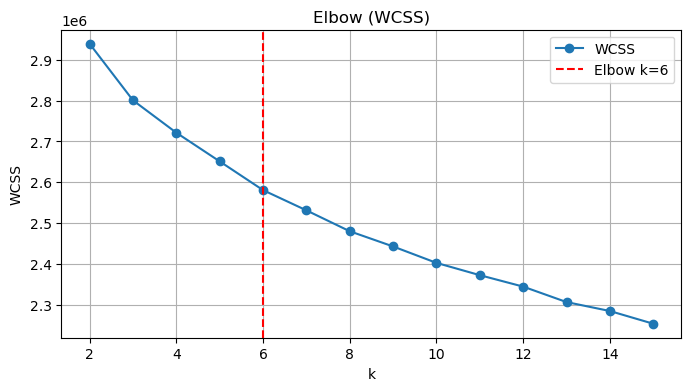

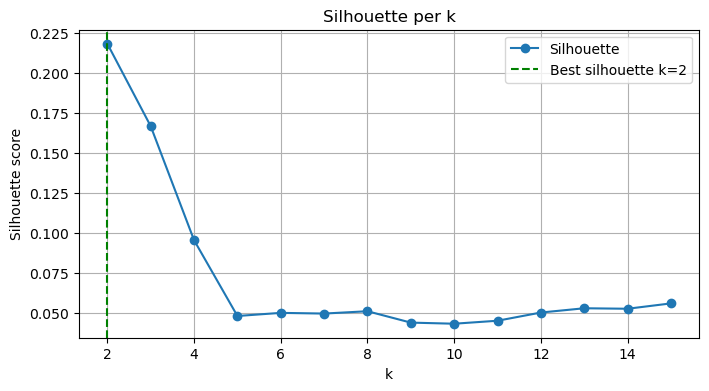

Elbow k: 6 | Best silhouette k: 2 | Selected k_opt: 6

Assigned Structure_Cluster using RDKit features with k=6.
                                              SMILES  Structure_Cluster
0  FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...                  1
1                                       CCc1ncc[nH]1                  2
2                        S=C(N(C)C)Sc1ccc2c(c1)cccc2                  5
3                             Nc1nc(N)nc(n1)c1ccccc1                  0
4                         NCCNc1ccc(cn1)[N+](=O)[O-]                  0

✅ Clustered High-Mw dataset saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_low&int_MP_scaled_clustered.csv


In [ ]:
# ========= Clustering RDKit features for Low&Int-Mw data =========
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# ---------------------------------------------------------------------
# 1) Load Low-Mw scaled dataset
# ---------------------------------------------------------------------
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"
high_mw_train_path = artifacts_dir / "final_train_low_and_intermediate_MP_scaled.csv"

int_df = pd.read_csv(high_mw_train_path)
print("Loaded Low&Int-MP scaled data:", int_df.shape)

# ---------------------------------------------------------------------
# 2) Select RDKit features only
# ---------------------------------------------------------------------
# Exclude non-feature columns
exclude_cols = ["SMILES", "MP", "MW", "MP_category_default"]
rdk_cols = [c for c in int_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(int_df[c])]

X_rdk_scaled = int_df[rdk_cols].values
print(f"RDKit feature matrix shape: {X_rdk_scaled.shape}")

# ---------------------------------------------------------------------
# 3) Function: Find optimal k for KMeans
# ---------------------------------------------------------------------
def find_optimal_clusters_rdk(X_scaled, max_k=15, random_state=0, plot=True):
    ks, wcss, sils = list(range(2, max_k + 1)), [], []
    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        try:
            sils.append(silhouette_score(X_scaled, labels))
        except Exception:
            sils.append(np.nan)

    kn = KneeLocator(ks, wcss, curve="convex", direction="decreasing")
    k_elbow = kn.elbow
    k_sil = ks[int(np.nanargmax(sils))] if np.isfinite(sils).any() else None
    k_opt = k_elbow if k_elbow is not None else k_sil

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, wcss, marker="o", label="WCSS")
        if k_elbow is not None:
            ax.axvline(k_elbow, linestyle="--", color="r", label=f"Elbow k={k_elbow}")
        ax.set(xlabel="k", ylabel="WCSS", title="Elbow (WCSS)")
        ax.grid(True); ax.legend(); plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, sils, marker="o", label="Silhouette")
        if k_sil is not None:
            ax.axvline(k_sil, linestyle="--", color="g", label=f"Best silhouette k={k_sil}")
        ax.set(xlabel="k", ylabel="Silhouette score", title="Silhouette per k")
        ax.grid(True); ax.legend(); plt.show()

    print(f"Elbow k: {k_elbow} | Best silhouette k: {k_sil} | Selected k_opt: {k_opt}")
    return k_opt

# ---------------------------------------------------------------------
# 4) Find optimal number of clusters
# ---------------------------------------------------------------------
k_opt = find_optimal_clusters_rdk(X_rdk_scaled, max_k=15, random_state=0, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

# ---------------------------------------------------------------------
# 5) Apply KMeans clustering
# ---------------------------------------------------------------------
final_kmeans = KMeans(n_clusters=int(k_opt), init="k-means++", n_init=10, random_state=0)
int_df["Structure_Cluster"] = final_kmeans.fit_predict(X_rdk_scaled)

print(f"\nAssigned Structure_Cluster using RDKit features with k={k_opt}.")
print(int_df[["SMILES", "Structure_Cluster"]].head())

# ---------------------------------------------------------------------
# 6) Save the clustered dataset
# ---------------------------------------------------------------------
clustered_out_path = artifacts_dir / "final_train_low&int_MP_scaled_clustered.csv"
int_df.to_csv(clustered_out_path, index=False)
print(f"\n✅ Clustered High-Mw dataset saved to: {clustered_out_path}")

In [53]:
# DATA preparation for classifier model (binary)

from pathlib import Path
import pandas as pd

BASE = Path.cwd()
artifacts = BASE / "artifacts"

df = pd.read_csv(artifacts / "final_train_df_scaled.csv")

df["MP_binary_high"] = (df["MP_category_default"] == "High").astype("int8")

print(df["MP_binary_high"].value_counts())

df.to_csv(
    artifacts / "final_train_scaled_binary.csv",
    index=False
)


MP_binary_high
0    16853
1      772
Name: count, dtype: int64


Loaded binary scaled data: (17625, 207)
RDKit feature matrix shape: (17625, 202)
Number of RDKit feature cols used: 202


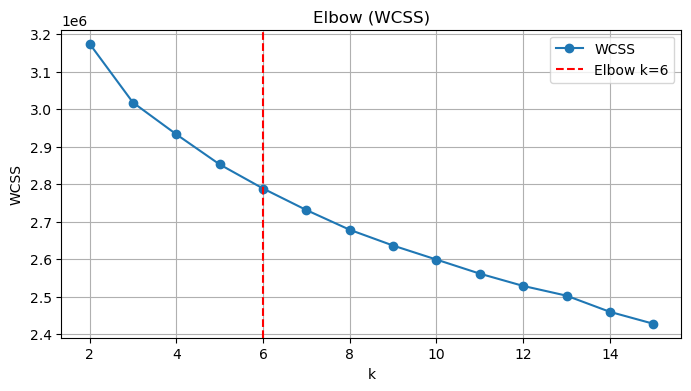

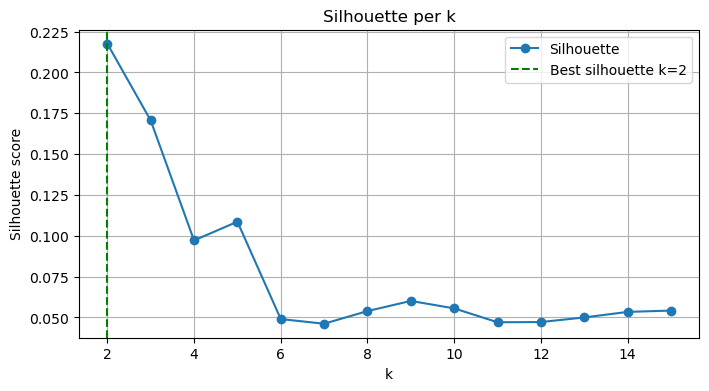

Elbow k: 6 | Best silhouette k: 2 | Selected k_opt: 6

Assigned Structure_Cluster using RDKit features with k=6.
                                              SMILES  Structure_Cluster
0  FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...                  1
1                                       CCc1ncc[nH]1                  5
2                        S=C(N(C)C)Sc1ccc2c(c1)cccc2                  3
3                             Nc1nc(N)nc(n1)c1ccccc1                  2
4                         NCCNc1ccc(cn1)[N+](=O)[O-]                  2

✅ Clustered binary dataset saved to: /Users/sdl5_mp/Documents/GitHub/SDL5_MP/transfer_learning/artifacts/final_train_scaled_binary_clustered.csv


In [54]:
# ========= Clustering RDKit features for Binary-classifier train data =========
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# ---------------------------------------------------------------------
# 1) Load binary scaled dataset
# ---------------------------------------------------------------------
BASE = Path.cwd()  # transfer_learning
artifacts_dir = BASE / "artifacts"
binary_train_path = artifacts_dir / "final_train_scaled_binary.csv"

bin_df = pd.read_csv(binary_train_path)
print("Loaded binary scaled data:", bin_df.shape)

# ---------------------------------------------------------------------
# 2) Select RDKit features only
# ---------------------------------------------------------------------
# Exclude non-feature columns (keep consistent with your other scripts)
exclude_cols = ["SMILES", "MP", "MW", "MP_category_default", "MP_binary_high"]

rdk_cols = [
    c for c in bin_df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(bin_df[c])
]

X_rdk_scaled = bin_df[rdk_cols].values
print(f"RDKit feature matrix shape: {X_rdk_scaled.shape}")
print(f"Number of RDKit feature cols used: {len(rdk_cols)}")

# ---------------------------------------------------------------------
# 3) Function: Find optimal k for KMeans
# ---------------------------------------------------------------------
def find_optimal_clusters_rdk(X_scaled, max_k=15, random_state=0, plot=True):
    ks, wcss, sils = list(range(2, max_k + 1)), [], []
    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        try:
            sils.append(silhouette_score(X_scaled, labels))
        except Exception:
            sils.append(np.nan)

    kn = KneeLocator(ks, wcss, curve="convex", direction="decreasing")
    k_elbow = kn.elbow
    k_sil = ks[int(np.nanargmax(sils))] if np.isfinite(sils).any() else None
    k_opt = k_elbow if k_elbow is not None else k_sil

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, wcss, marker="o", label="WCSS")
        if k_elbow is not None:
            ax.axvline(k_elbow, linestyle="--", color="r", label=f"Elbow k={k_elbow}")
        ax.set(xlabel="k", ylabel="WCSS", title="Elbow (WCSS)")
        ax.grid(True); ax.legend(); plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, sils, marker="o", label="Silhouette")
        if k_sil is not None:
            ax.axvline(k_sil, linestyle="--", color="g", label=f"Best silhouette k={k_sil}")
        ax.set(xlabel="k", ylabel="Silhouette score", title="Silhouette per k")
        ax.grid(True); ax.legend(); plt.show()

    print(f"Elbow k: {k_elbow} | Best silhouette k: {k_sil} | Selected k_opt: {k_opt}")
    return k_opt

# ---------------------------------------------------------------------
# 4) Find optimal number of clusters
# ---------------------------------------------------------------------
k_opt = find_optimal_clusters_rdk(X_rdk_scaled, max_k=15, random_state=0, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

# ---------------------------------------------------------------------
# 5) Apply KMeans clustering
# ---------------------------------------------------------------------
final_kmeans = KMeans(n_clusters=int(k_opt), init="k-means++", n_init=10, random_state=0)
bin_df["Structure_Cluster"] = final_kmeans.fit_predict(X_rdk_scaled)

print(f"\nAssigned Structure_Cluster using RDKit features with k={k_opt}.")
print(bin_df[["SMILES", "Structure_Cluster"]].head())

# ---------------------------------------------------------------------
# 6) Save the clustered dataset
# ---------------------------------------------------------------------
clustered_out_path = artifacts_dir / "final_train_scaled_binary_clustered.csv"
bin_df.to_csv(clustered_out_path, index=False)
print(f"\n✅ Clustered binary dataset saved to: {clustered_out_path}")


In [ ]:
from sklearn.manifold import TSNE

def plot_cluster_tSNE(X, labels, title="t-SNE Clustering", perplexity=30):
    
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_embedded = tsne.fit_transform(X)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=labels, palette='viridis', s=50)
    plt.title(title)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

plot_cluster_tSNE(X, final_train_df["Structure_Cluster"], title="t-SNE Clustering of Structure Clusters", perplexity=30)

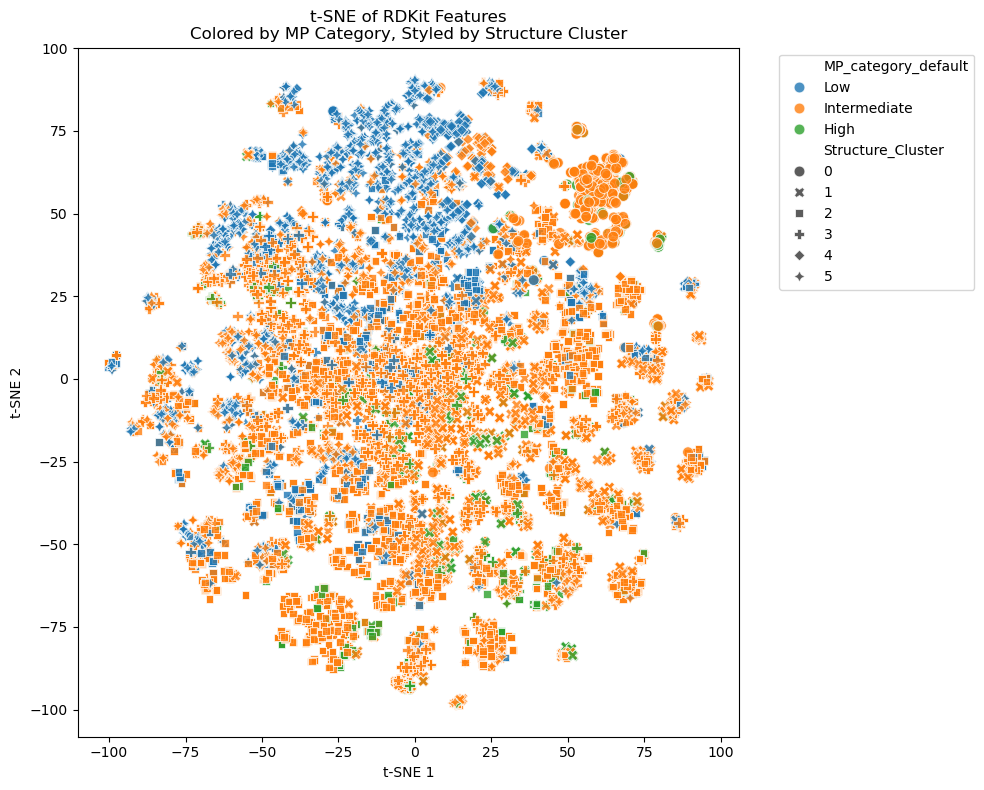

In [56]:
from sklearn.manifold import TSNE
import seaborn as sns

assert "Structure_Cluster" in bin_df.columns
assert "MP_category_default" in bin_df.columns

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42,
)

X_tsne = tsne.fit_transform(X_rdk_scaled)

bin_df["tSNE_1"] = X_tsne[:, 0]
bin_df["tSNE_2"] = X_tsne[:, 1]

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=bin_df,
    x="tSNE_1",
    y="tSNE_2",
    hue="MP_category_default",        # Low / Intermediate / High
    style="Structure_Cluster",        # cluster number
    palette={
        "Low": "#1f77b4",
        "Intermediate": "#ff7f0e",
        "High": "#2ca02c",
    },
    alpha=0.8,
    s=60,
)

plt.title("t-SNE of RDKit Features\nColored by MP Category, Styled by Structure Cluster")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()




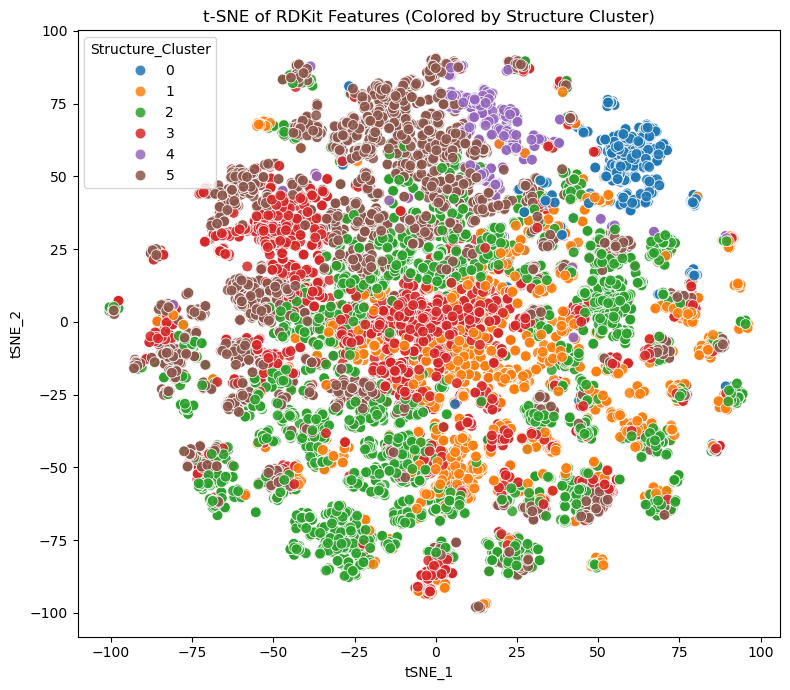

In [57]:
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=bin_df,
    x="tSNE_1",
    y="tSNE_2",
    hue="Structure_Cluster",
    palette="tab10",
    alpha=0.85,
    s=60,
)

plt.title("t-SNE of RDKit Features (Colored by Structure Cluster)")
plt.tight_layout()
plt.show()


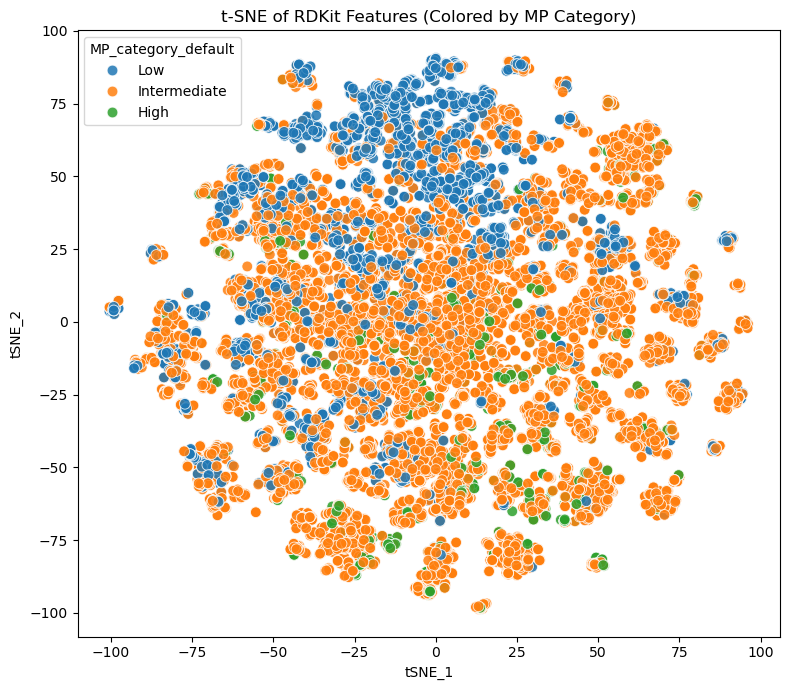

In [58]:
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=bin_df,
    x="tSNE_1",
    y="tSNE_2",
    hue="MP_category_default",
    palette={
        "Low": "#1f77b4",
        "Intermediate": "#ff7f0e",
        "High": "#2ca02c",
    },
    alpha=0.85,
    s=60,
)

plt.title("t-SNE of RDKit Features (Colored by MP Category)")
plt.tight_layout()
plt.show()


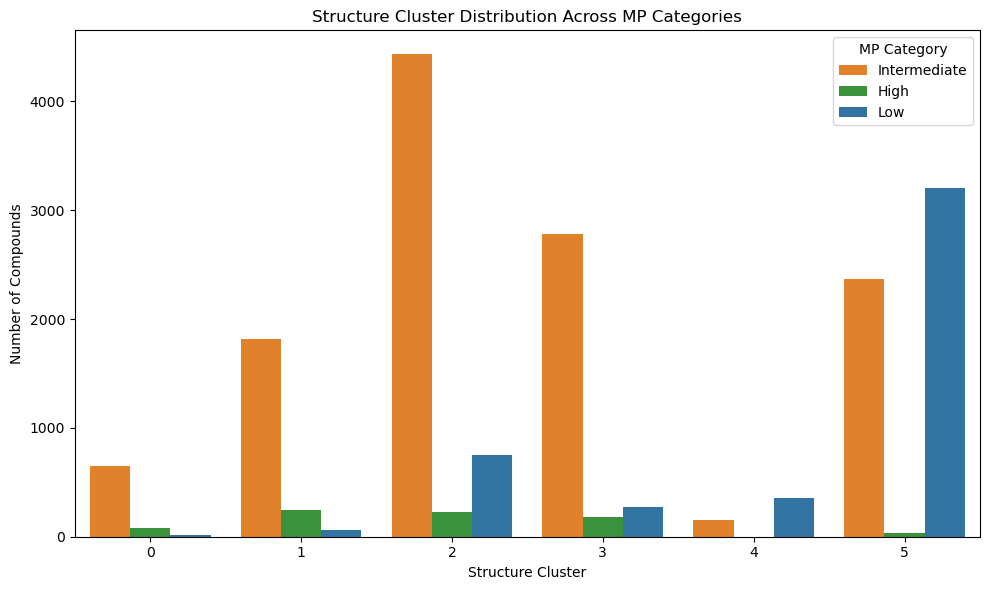

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=bin_df,
    x="Structure_Cluster",
    hue="MP_category_default",
    palette={
        "Low": "#1f77b4",
        "Intermediate": "#ff7f0e",
        "High": "#2ca02c",
    },
)

plt.title("Structure Cluster Distribution Across MP Categories")
plt.xlabel("Structure Cluster")
plt.ylabel("Number of Compounds")
plt.legend(title="MP Category")
plt.tight_layout()
plt.show()


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_40382/4231349595.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


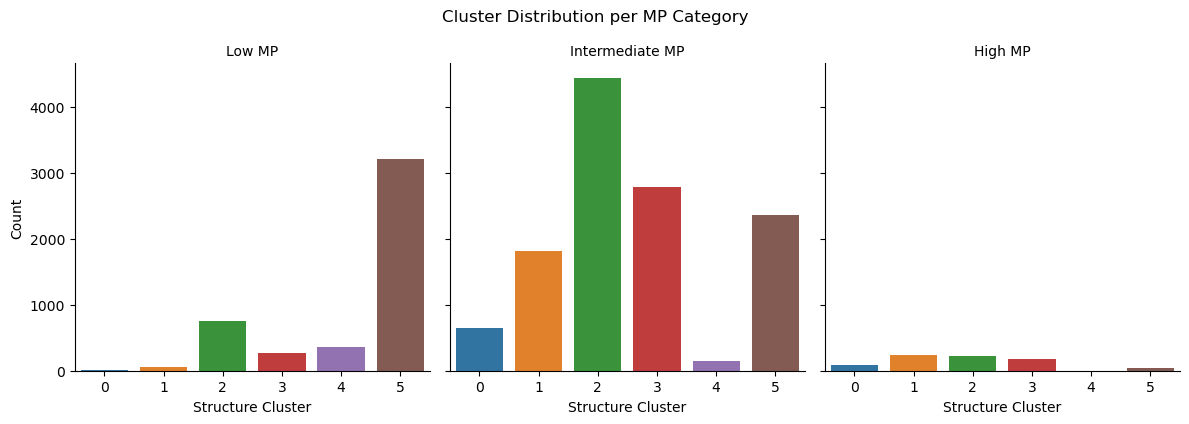

In [65]:
g = sns.catplot(
    data=bin_df,
    x="Structure_Cluster",
    col="MP_category_default",
    kind="count",
    col_order=["Low", "Intermediate", "High"],
    height=4,
    aspect=1,
    sharey=True,
    palette="tab10",
)

g.set_axis_labels("Structure Cluster", "Count")
g.set_titles("{col_name} MP")
g.fig.suptitle("Cluster Distribution per MP Category", y=1.05)
plt.show()


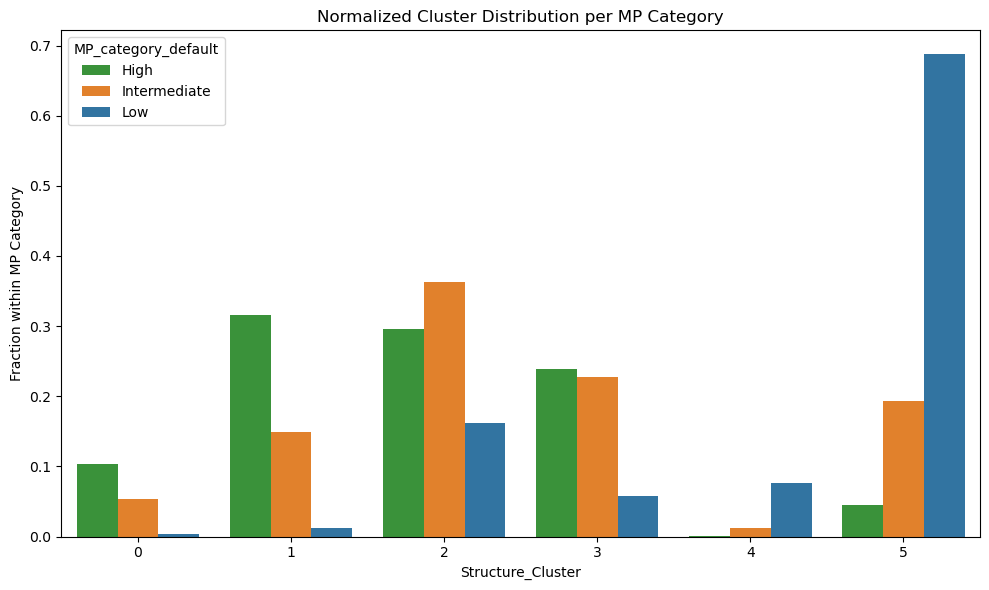

In [66]:
# Normalize counts within each MP category
dist_df = (
    bin_df
    .groupby(["MP_category_default", "Structure_Cluster"])
    .size()
    .reset_index(name="count")
)

dist_df["fraction"] = dist_df.groupby("MP_category_default")["count"].transform(
    lambda x: x / x.sum()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=dist_df,
    x="Structure_Cluster",
    y="fraction",
    hue="MP_category_default",
    palette={
        "Low": "#1f77b4",
        "Intermediate": "#ff7f0e",
        "High": "#2ca02c",
    },
)

plt.ylabel("Fraction within MP Category")
plt.title("Normalized Cluster Distribution per MP Category")
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import pandas as pd

# Paths
BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
scaled_train_path = artifacts_dir / "final_train_df_scaled.csv"

# Load scaled train data
train_scaled_df = pd.read_csv(scaled_train_path)
print("Loaded scaled train:", train_scaled_df.shape)

# Check category distribution
print(train_scaled_df["MP_category_default"].value_counts())

# Split by MW_category_default
low_df  = train_scaled_df[train_scaled_df["MP_category_default"] == "Low"].copy()
mid_df  = train_scaled_df[train_scaled_df["MP_category_default"] == "Intermediate"].copy()
high_df = train_scaled_df[train_scaled_df["MP_category_default"] == "High"].copy()

# Save each subset
low_path  = artifacts_dir / "final_train_low_MP_scaled.csv"
mid_path  = artifacts_dir / "final_train_intermediate_MP_scaled.csv"
high_path = artifacts_dir / "final_train_high_MP_scaled.csv"

low_df.to_csv(low_path, index=False)
mid_df.to_csv(mid_path, index=False)
high_df.to_csv(high_path, index=False)

print("\n✅ Split complete:")
print(f"Low-MP dataset saved to:          {low_path}   ({len(low_df)} rows)")
print(f"Intermediate-MP dataset saved to: {mid_path}   ({len(mid_df)} rows)")
print(f"High-MP dataset saved to:         {high_path}  ({len(high_df)} rows)")


In [ ]:

# ========= TEST: keep 4 cols → Mw filter → MW category → RDKit → clean & save =========

# ---------- 1) Load and keep only the 4 columns ----------
raw_test = pd.read_csv(test_csv).rename(columns={"SMLIES": "SMILES", "MW": "Mw"})
cols_to_keep = ["SMILES", "exp MP", "embeddings", "Mw"]
missing = [c for c in cols_to_keep if c not in raw_test.columns]
if missing:
    print("Warning: missing expected columns in TEST:", missing)
test_df = raw_test[[c for c in cols_to_keep if c in raw_test.columns]].copy()

# ---------- 2) Mw ≤ 1000 filter ----------
print("Before filtering:", test_df.shape)
test_df = test_df[test_df["Mw"] <= 1000].copy()
print("After filtering:", test_df.shape)

# ---------- 3) MW category (same thresholds as train) ----------
t1, t2 = 250, 500
print(f"Ranges (based on TRAIN): Low ≤ {t1}, Intermediate ({t1}, {t2}], High > {t2}")
test_df["MW_category"] = mw_default_thresholds(test_df["Mw"], t1=t1, t2=t2)

# ---------- 4) RDKit descriptors for TEST ----------
merged_test_df, invalid_test = add_rdkit_descriptors(
    test_df,
    smiles_col="SMILES",
    invalid_log_path=artifacts_dir / "invalid_smiles_test.csv"
)

# ---------- 5) Clean RDKit columns: drop any NaN/∞ and zero-variance ----------
base_cols_test = set(test_df.columns)  # columns BEFORE adding RDKit
rdkit_cols_test = [c for c in merged_test_df.columns if c not in base_cols_test]

dft = merged_test_df.copy()
# Replace ±Inf with NaN (RDKit cols only)
dft[rdkit_cols_test] = dft[rdkit_cols_test].replace([np.inf, -np.inf], np.nan)

# Drop any RDKit columns containing NaN
nan_inf_cols_t = [c for c in rdkit_cols_test if dft[c].isna().any()]

# From remaining, drop zero-variance RDKit columns
remaining_cols_t = [c for c in rdkit_cols_test if c not in nan_inf_cols_t]
remaining_numeric_t = [c for c in remaining_cols_t if pd.api.types.is_numeric_dtype(dft[c])]
nunique_t = dft[remaining_numeric_t].nunique(dropna=False)
zero_var_cols_t = nunique_t.index[nunique_t <= 1].tolist()

# Drop log (with reasons)
all_drop_t = sorted(set(nan_inf_cols_t).union(zero_var_cols_t))
reasons_t = []
for col in all_drop_t:
    r = []
    if col in nan_inf_cols_t: r.append("nan_or_inf")
    if col in zero_var_cols_t: r.append("zero_variance")
    reasons_t.append(";".join(r))

dropped_log_t = pd.DataFrame({"feature": all_drop_t, "reason": reasons_t})
dropped_log_t_path = artifacts_dir / "rdkit_features_dropped_log_test.csv"
dropped_log_t.to_csv(dropped_log_t_path, index=False)

# Build final cleaned TEST
keep_cols_t = [c for c in dft.columns if c not in set(all_drop_t)]
final_test_clean = dft[keep_cols_t].copy()

# ---------- 6) Save outputs ----------
raw_test_out   = artifacts_dir / "final_test_df_with_rdkit_all_descriptors.csv"
final_test_out = artifacts_dir / "final_test_df_with_rdkit_all_descriptors_cleaned.csv"
retained_list  = artifacts_dir / "rdkit_features_retained_test.csv"

merged_test_df.to_csv(raw_test_out, index=False)
final_test_clean.to_csv(final_test_out, index=False)
pd.Series([c for c in rdkit_cols_test if c not in set(all_drop_t)],
          name="retained_rdkit_features").to_csv(retained_list, index=False)

print("\n=== TEST REPORT ===")
print(f"Total RDKit features originally: {len(rdkit_cols_test)}")
print(f"Dropped (NaN/∞): {len(nan_inf_cols_t)}")
print(f"Dropped (zero variance): {len(zero_var_cols_t)}")
print(f"Remaining RDKit features: {len(rdkit_cols_test) - len(all_drop_t)}")
print(f"Saved RAW merged       -> {raw_test_out}")
print(f"Saved CLEANED dataset  -> {final_test_out}")
print(f"Saved invalid SMILES   -> {artifacts_dir / 'invalid_smiles_test.csv'}")
print(f"Saved drop log         -> {dropped_log_t_path}")
print(f"Saved retained list    -> {retained_list}")



In [94]:
import pandas as pd
from pathlib import Path

BASE = Path.cwd()
PROJECT_ROOT = BASE.parent

test_file_path = (PROJECT_ROOT/ "data_curation"/ "original_curated_with_embeddings_and_MW"/ "test_predictions"/ "consensus_without_data_augmentation.csv")

df = pd.read_csv(test_file_path)

print("Number of data points:", len(df))


Number of data points: 1961


In [ ]:
# TEST SET
test_file_df = BASE / "data_curation" / "original_curated_with_embeddings_and_MW" / "test_predictions" / "consensus_without_data_augmentation.csv"
# only keep SMILES, exp MP, embeddings, Mw for test


df = pd.read_csv(test_file_df)
cols_to_keep = ["SMILES", "exp MP", "embeddings", "Mw"]     # Select desired columns
test_df = df[cols_to_keep].copy()

# 0) Remove compounds with Mw > 1000
print("Before filtering:", test_df.shape)
test_df = test_df[test_df["Mw"] <= 1000].copy()
print("After filtering:", test_df.shape)

# 1) Define MW thresholds
t1, t2 = 250, 500
print(f"Ranges (based on TRAIN): Low ≤ {t1}, Intermediate ({t1}, {t2}], High > {t2}")

# 2) Define function for MW classification
def mw_default_thresholds(mw_series, t1=250, t2=500):
    return np.select(
        [mw_series <= t1, mw_series > t2],
        ["Low", "High"],
        default="Intermediate"
    )

# 3) Apply classification function to test dataset
test_df["MW_category"] = mw_default_thresholds(test_df["Mw"], t1=t1, t2=t2)












# Save filtered dataset
output_path = test_file_dir.parent / "test_filtered_embeddings_Mw.csv"
filtered_df.to_csv(output_path, index=False)

print(f"Filtered dataset saved to: {output_path}")






test_df["MW_category_default"]  = mw_default_thresholds(test_df["MW"],  t1, t2)



# Save to new CSV
output_path = test_file_dir.parent / "test_filtered_embeddings_Mw.csv"
filtered_df.to_csv(output_path, index=False)

print(f"Filtered dataset saved to: {output_path}")
print(filtered_df.head())

In [ ]:
# Add RDKit features 


# Featurization of features and remove the columns with NaN or infinity values


# Save files for train and test all with RDKit, before scaling



In [ ]:
# Scaling for TRAIN ONLY


# Save file for train_scaled


# Save Scaler


# Scale test with the same scaler and save test_scaled


